In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow
from tensorflow import keras 
from keras.layers import Dense 
from keras.models import Sequential
from keras.optimizers import SGD

In [37]:
df = pd.read_csv('ushape.csv')

In [38]:
df.head()

,X,Y,class
0,0.031595,0.986988,0.0
1,2.115098,-0.046244,1.0
2,0.882490,-0.075756,0.0
3,-0.055144,-0.037332,1.0
4,0.829545,-0.539321,1.0


In [39]:
model = Sequential()

model.add(Dense(256 , activation= 'relu' , input_dim = 2))
model.add(Dense(128 , activation= 'relu'))
model.add(Dense(56 , activation= 'relu'))
model.add(Dense(1 , activation= 'sigmoid'))

model.summary()

c:\Users\Acer\anaconda3\envs\santoshenv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 56)             │         7,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            57 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,945 (159.94 KB)

 Trainable params: 40,945 (159.94 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
sgd = SGD(momentum= 0.9)

model.compile(loss = 'binary_crossentropy' , optimizer= sgd ,metrics= ['accuracy'])

In [41]:
from keras.callbacks import EarlyStopping
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=50,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
)

In [43]:
history = model.fit(df.iloc[: , 0:2].values , df.iloc[: , -1].values,  validation_split= 0.2 ,epochs= 200, callbacks= callback , verbose= False)

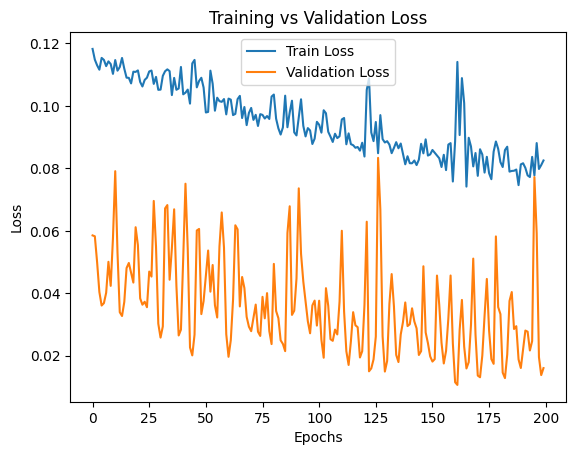

In [44]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

We can see huge spikes which is occur due to high momentum.